In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display
from plotter import plot_series

import sys
sys.path.insert(0, str(Path("..").resolve()))
from run_registry import latest_entry, steps_path

RUNS_DIR = Path("../runs")


def load_run(**filters) -> pd.DataFrame:
    """Load steps for the latest registry match. Pass any of:
    strategy, id, folder, assets, params, start_date, end_date.
    """
    entry = latest_entry(RUNS_DIR, **filters)
    #print(entry)
    return pd.read_json(steps_path(RUNS_DIR, entry), lines=True)


In [ ]:
runs = {
    "hold_btc": load_run(strategy="hold", assets="BTC"),
    "buybelow_btc": load_run(strategy="buybelow", assets="BTC"),
}

# for name, steps in runs.items():
#     display(steps)


,step,time,prices,decision,cancel_order_ids,filled_order_ids,open_orders,balances,positions,equity
0,0,2023-01-01 00:00:00,"{'BTC': '16616.75', 'ETH': '1200.34'}","[{'id': 'o1', 'ticker': 'BTC', 'side': 'BUY', ...",[],[o1],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",10000.000000
1,1,2023-01-02 00:00:00,"{'BTC': '16672.87', 'ETH': '1214.0'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",10033.773151
2,2,2023-01-03 00:00:00,"{'BTC': '16675.18', 'ETH': '1214.55'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",10035.163314
3,3,2023-01-04 00:00:00,"{'BTC': '16850.36', 'ETH': '1256.9'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",10140.587058
4,4,2023-01-05 00:00:00,"{'BTC': '16831.85', 'ETH': '1251.24'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",10129.447696
...,...,...,...,...,...,...,...,...,...,...
726,726,2024-12-27 00:00:00,"{'BTC': '94299.03', 'ETH': '3333.51'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",56749.382400
727,727,2024-12-28 00:00:00,"{'BTC': '95300.0', 'ETH': '3404.0'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",57351.768547
728,728,2024-12-29 00:00:00,"{'BTC': '93738.2', 'ETH': '3356.48'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",56411.873561
729,729,2024-12-30 00:00:00,"{'BTC': '92792.05', 'ETH': '3361.84'}",[],[],[],[],{'USD': '0E-23'},"[{'ticker': 'BTC', 'quantity': '0.601802398182...",55842.478222


,step,time,prices,decision,cancel_order_ids,filled_order_ids,open_orders,balances,positions,equity
0,0,2023-01-01 00:00:00,"{'BTC': '16616.75', 'ETH': '1200.34'}","[{'id': 'o2', 'ticker': 'BTC', 'side': 'BUY', ...",[],[],"[{'id': 'o2', 'ticker': 'BTC', 'side': 'BUY', ...",{'USD': '10000'},[],10000.000
1,1,2023-01-02 00:00:00,"{'BTC': '16672.87', 'ETH': '1214.0'}",[],[],[o2],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",8336.435
2,2,2023-01-03 00:00:00,"{'BTC': '16675.18', 'ETH': '1214.55'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",8337.590
3,3,2023-01-04 00:00:00,"{'BTC': '16850.36', 'ETH': '1256.9'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",8425.180
4,4,2023-01-05 00:00:00,"{'BTC': '16831.85', 'ETH': '1251.24'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",8415.925
...,...,...,...,...,...,...,...,...,...,...
726,726,2024-12-27 00:00:00,"{'BTC': '94299.03', 'ETH': '3333.51'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",47149.515
727,727,2024-12-28 00:00:00,"{'BTC': '95300.0', 'ETH': '3404.0'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",47650.000
728,728,2024-12-29 00:00:00,"{'BTC': '93738.2', 'ETH': '3356.48'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",46869.100
729,729,2024-12-30 00:00:00,"{'BTC': '92792.05', 'ETH': '3361.84'}",[],[],[],[],{'USD': '0.0'},"[{'ticker': 'BTC', 'quantity': '0.5', 'average...",46396.025


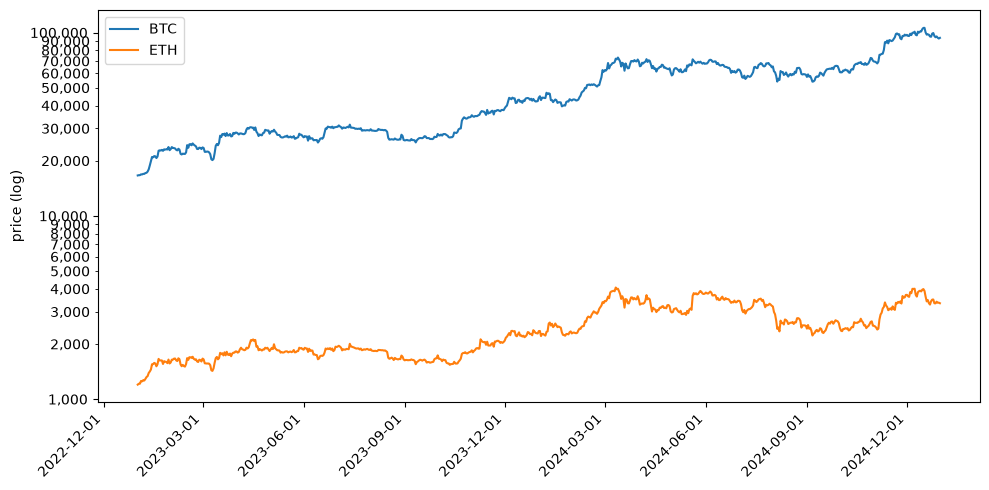

In [7]:
# Market prices (from either run — both have BTC + ETH in `prices`)
market = runs["hold_btc"]
price_frames = {}
for asset in ["BTC", "ETH"]:
    frame = market[["time", "prices"]].copy()
    frame["price"] = frame["prices"].map(lambda prices: float(prices[asset]))
    price_frames[asset] = frame

plot_series(price_frames, "price")


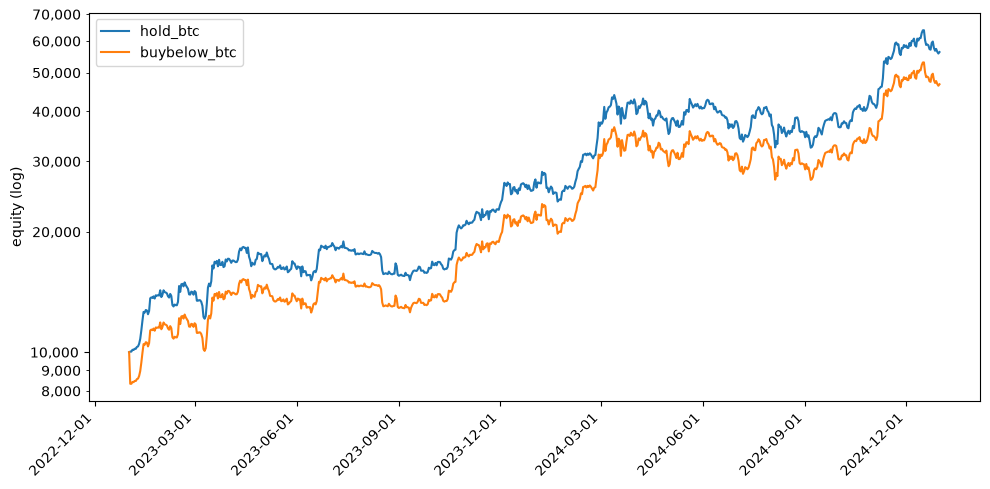

In [8]:
plot_series(runs, "equity")
